# re_nilm — Full Library Demo

This notebook is the detailed companion to `README.md`. It walks through the library from the lowest-level detector calls up to the full portfolio pipeline and exported figures.

The repository expects Romande Energie style 15-minute parquet files with `ID`, `DT_UTC`, `CONSO_KWH`, and `PROD_KWH`. The production config also filters the cohort to `Particuliers` customers below 100 MWh annual consumption.

Notebook sections:

1. **Setup and inputs** — resolve paths, load config, load/cache weather, build the filtered customer index.
2. **Single customer** — run detectors and estimators directly for one customer.
3. **Train models** — retrain AC / HP classifiers when labelled Dataport data is available.
4. **Small portfolio** — run heuristic detectors on a bounded customer sample for quick iteration.
5. **Full portfolio** — run or load the orchestrated pipeline outputs and inspect portfolio results.
6. **CLI reference** — equivalent commands for production runs and figure export.

Most expensive cells are opt-in. Keep `RUN_FULL_PIPELINE = False` unless you intentionally want to launch the full pipeline from this notebook.

In [18]:
import sys
from pathlib import Path

# Resolve the repository root whether the notebook is launched from repo/ or repo/notebooks/.
cwd = Path().resolve()
REPO = cwd.parent if cwd.name == "notebooks" else cwd
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from re_nilm.pipeline.orchestrator import load_config

CONFIG_PATH = REPO / "config" / "re_production.yaml"
cfg = load_config(CONFIG_PATH)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print(f"Repo: {REPO}")
print(f"Config: {CONFIG_PATH}")

Repo: /Users/alan/Desktop/ETH/cs_re/Mest_RE_25
Config: /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/config/re_production.yaml


In [19]:
from pathlib import Path
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
pv_path = REPO / "data" / "processed" / "out" / "pv_indicators.parquet"

df = pd.read_parquet(pv_path)
pv_ids = df.loc[df["has_pv"] == True, "customer_id"].tolist()

In [20]:
len(pv_ids)

16556

In [21]:
# ── Paths from YAML config ────────────────────────────────────────────────────
def repo_path(value):
    path = Path(value)
    return path if path.is_absolute() else REPO / path

DATA_DIR = repo_path(cfg.get("data", {}).get("re_data_dir", "data/raw/re"))
METADATA_DIR = repo_path(cfg.get("data", {}).get("metadata_dir", DATA_DIR))
RESULTS_DIR = repo_path(cfg.get("output", {}).get("results_dir", "data/processed/out"))
FIGURES_DIR = repo_path(cfg.get("output", {}).get("figures_dir", "figures/results"))
RESULTS_FILE = RESULTS_DIR / "results_all_customers.parquet"

# WeatherLoader writes cache files like weather_meteoswiss_None_None.parquet.
WEATHER_CANDIDATES = sorted(RESULTS_DIR.glob("weather_meteoswiss_*.parquet"))
WEATHER_CACHE = WEATHER_CANDIDATES[-1] if WEATHER_CANDIDATES else RESULTS_DIR / "weather_meteoswiss_None_None.parquet"

# Optional legacy/reference outputs used only as fallback examples.
REF_CAPACITY = REPO / "data" / "out" / "capacity_autosave.parquet"
REF_INDICATORS = REPO / "data" / "out" / "pv_indicators_clean.parquet"

print("Data dir exists:", DATA_DIR.exists(), DATA_DIR)
print("Metadata dir exists:", METADATA_DIR.exists(), METADATA_DIR)
print("Results dir:", RESULTS_DIR)
print("Weather cache exists:", WEATHER_CACHE.exists(), WEATHER_CACHE.name)
print("Full results exist:", RESULTS_FILE.exists())
print("Configured cohort:", cfg.get("data", {}).get("customer_type_filter"), "<=", cfg.get("data", {}).get("max_consumption_kwh"), "kWh")

Data dir exists: True /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/data/re_data/ETHZ_ALL
Metadata dir exists: True /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/data/re_data/ETHZ_ALL
Results dir: /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/data/processed/out
Weather cache exists: True weather_meteoswiss_None_None.parquet
Full results exist: True
Configured cohort: Particuliers <= 100000 kWh


In [22]:
# ── Load or fetch weather (cached after first run) ─────────────────────────────
from re_nilm.data.loaders.weather import WeatherLoader

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
if WEATHER_CACHE.exists():
    weather = pd.read_parquet(WEATHER_CACHE)
    print(f"Weather loaded from cache: {len(weather):,} rows, "
          f"{weather.dt_utc.min().date()} → {weather.dt_utc.max().date()}")
else:
    print("Fetching MeteoSwiss weather data and caching it in output.results_dir...")
    weather = WeatherLoader(backend="meteoswiss", cache_dir=RESULTS_DIR).load()
    print(f"Weather fetched: {len(weather):,} rows")

Weather loaded from cache: 210,432 rows, 2020-01-01 → 2025-12-31


---
## Pipeline Architecture At A Glance

The orchestrated pipeline is configured by `config/default.yaml` plus `config/re_production.yaml`. It runs this sequence:

1. Load/cache weather in `output.results_dir`.
2. Build `customer_file_index.json` with the configured customer segment and consumption cap.
3. Stream scalar detector/estimator steps: PV, PV capacity, battery, AC, heat pump, and EV.
4. Optionally write large 15-minute outputs for AC disaggregation, HP disaggregation, and EV sessions.
5. Join scalar outputs into `results_all_customers.parquet`.
6. Export portfolio figures as PNG files with `scripts/export_figures.py`.

Each streamed step owns its own checkpoint. This matters when resuming: an existing final parquet makes the orchestrator skip that step, while an incomplete step resumes from that step's checkpoint log.

---
## 1  Single Customer

This section loads one customer and runs detectors directly. It is useful for debugging detector behavior because it bypasses the orchestrator and exposes intermediate values.

The customer index is still built with the same production cohort filters used by the pipeline: `customer_type_filter="Particuliers"` and `max_consumption_kwh=100_000` unless you changed them in YAML.

In [23]:
from re_nilm.pipeline.customer_index import build_customer_file_index, load_customer_from_index

index = build_customer_file_index(
    DATA_DIR,
    cache_path=RESULTS_DIR / "customer_file_index.json",
    customer_type_filter=cfg.get("data", {}).get("customer_type_filter", "Particuliers"),
    max_consumption_kwh=cfg.get("data", {}).get("max_consumption_kwh", 100_000),
)
all_ids = list(index.keys())
print(f"{len(all_ids):,} customers indexed after cohort filtering")

# Pick a customer known to have PV from reference/new results if available.
pv_ids = []
if RESULTS_FILE.exists():
    try:
        portfolio_hint = pd.read_parquet(RESULTS_FILE, columns=["customer_id", "pv_capacity_kwp"])
        pv_ids = portfolio_hint.loc[portfolio_hint.pv_capacity_kwp > 5, "customer_id"].astype(str).tolist()
    except Exception:
        pv_ids = []
elif REF_CAPACITY.exists():
    ref_cap = pd.read_parquet(REF_CAPACITY)
    pv_ids = ref_cap.loc[ref_cap.pv_capacity_kwp > 5, "customer_id"].astype(str).tolist()

if not all_ids:
    raise RuntimeError("No customers found after filtering. Check data paths, metadata, and consumption cap.")

DEMO_ID = next((c for c in pv_ids if c in index), all_ids[min(1, len(all_ids) - 1)])
customer_df = load_customer_from_index(DEMO_ID, index)
print(f"Customer: {DEMO_ID[:12]}...  rows: {len(customer_df):,}")
print(f"Date range: {customer_df.DT_UTC.min().date()} → {customer_df.DT_UTC.max().date()}")
customer_df.head(3)

19,167 customers indexed after cohort filtering
Customer: 000621b10e1f...  rows: 35,136
Date range: 2024-01-01 → 2024-12-31


,ID,DT_UTC,CONSO_KWH,PROD_KWH
0,000621b10e1f72f73d78a0574a124ea4a35ee310,2024-01-01 00:00:00,0.317,0.0
1,000621b10e1f72f73d78a0574a124ea4a35ee310,2024-01-01 00:15:00,0.314,0.0
2,000621b10e1f72f73d78a0574a124ea4a35ee310,2024-01-01 00:30:00,0.472,0.0


In [13]:
# ── Run all detectors ──────────────────────────────────────────────────────────
from re_nilm.detectors.pv import PVDetector
from re_nilm.estimators.pv_capacity import PVCapacityEstimator
from re_nilm.detectors.battery import BatteryDetector
from re_nilm.estimators.battery_capacity import BatteryCapacityEstimator
from re_nilm.detectors.ev import EVDetector
from re_nilm.estimators.ev_sessions import EVSessionEstimator

pv_det = PVDetector(corr_threshold=0.3, min_yearly_prod_kwh=1.0)
pv_cap = PVCapacityEstimator(bootstrap_n=200)
batt_det = BatteryDetector(enforce_pv_required=True)
batt_cap = BatteryCapacityEstimator()
ev_det = EVDetector(prob_threshold=0.3)
ev_sess = EVSessionEstimator()

pv_result   = pv_det.predict_customer(customer_df, weather)
cap_result  = pv_cap.estimate(customer_df, pv_result, weather) if pv_result else None
batt_result = batt_det.predict_customer(customer_df, weather, pv_result=pv_result)
batt_cap_r  = batt_cap.estimate(
    customer_df,
    {**(batt_result or {}), "pv_result": {**(pv_result or {}), **(cap_result or {})}},
    weather,
)
ev_result   = ev_det.predict_customer(customer_df, weather)
ev_sessions = ev_sess.estimate(customer_df, ev_result, weather) if ev_result else None

print("PV  :", pv_result)
print("Cap :", {k: round(v, 2) for k, v in (cap_result or {}).items() if isinstance(v, float)})
print("Batt:", batt_result)
print("EV  :", ev_result)

PV  : {'customer_id': '26c74f9f3492de1182f552e80900588ac2cfae87', 'has_pv': True, 'prob_pv': 1.0, 'yearly_prod_kwh': 7807.338, 'corr_prod_rad': 0.9022762783814878, 'DeltaProd': 13.878417721518986, 'DeltaNet': -15.510417721518989, 'beta_regression': 0.001758847540376874}
Cap : {'pv_capacity_kwp': 9.25, 'pv_ci_lower': 8.69, 'pv_ci_upper': 9.75, 'sc_share': 0.07, 'sc_ci_lower': 0.03, 'sc_ci_upper': 0.11}
Batt: {'customer_id': '26c74f9f3492de1182f552e80900588ac2cfae87', 'has_battery': False, 'prob_battery': 0.0197, 'battery_status': 'Success'}
EV  : {'customer_id': '26c74f9f3492de1182f552e80900588ac2cfae87', 'has_ev': True, 'prob_ev': 0.854, 'ev_grid_sessions': 123, 'ev_pv_sessions': 0, 'ev_total_sessions': 123, 'ev_yearly_mwh': 4.883, 'ev_filtered_out': False}


In [14]:
# ── AC / HP detectors (skip gracefully if model files missing) ─────────────────
from re_nilm.detectors.ac import ACDetector
from re_nilm.detectors.heat_pump import HeatPumpDetector

ac_path = REPO / "models" / "ac_detector_v1.joblib"
hp_path = REPO / "models" / "hp_detector_v1.joblib"

ac_result = hp_result = None
if ac_path.exists():
    ac_det = ACDetector.load(ac_path)
    ac_result = ac_det.predict_customer(customer_df, weather)
    print("AC :", ac_result)
else:
    print("AC detector model not found — train it first (Section 2)")

if hp_path.exists():
    hp_det = HeatPumpDetector.load(hp_path)
    hp_result = hp_det.predict_customer(customer_df, weather)
    print("HP :", hp_result)
else:
    print("HP detector model not found — train it first (Section 2)")

AC : {'customer_id': '26c74f9f3492de1182f552e80900588ac2cfae87', 'has_ac': True, 'prob_ac': 0.7761528272255979}
HP : {'customer_id': '26c74f9f3492de1182f552e80900588ac2cfae87', 'has_hp': False, 'prob_hp': 0.009392420964477632, 'hp_type': 'no_hp'}


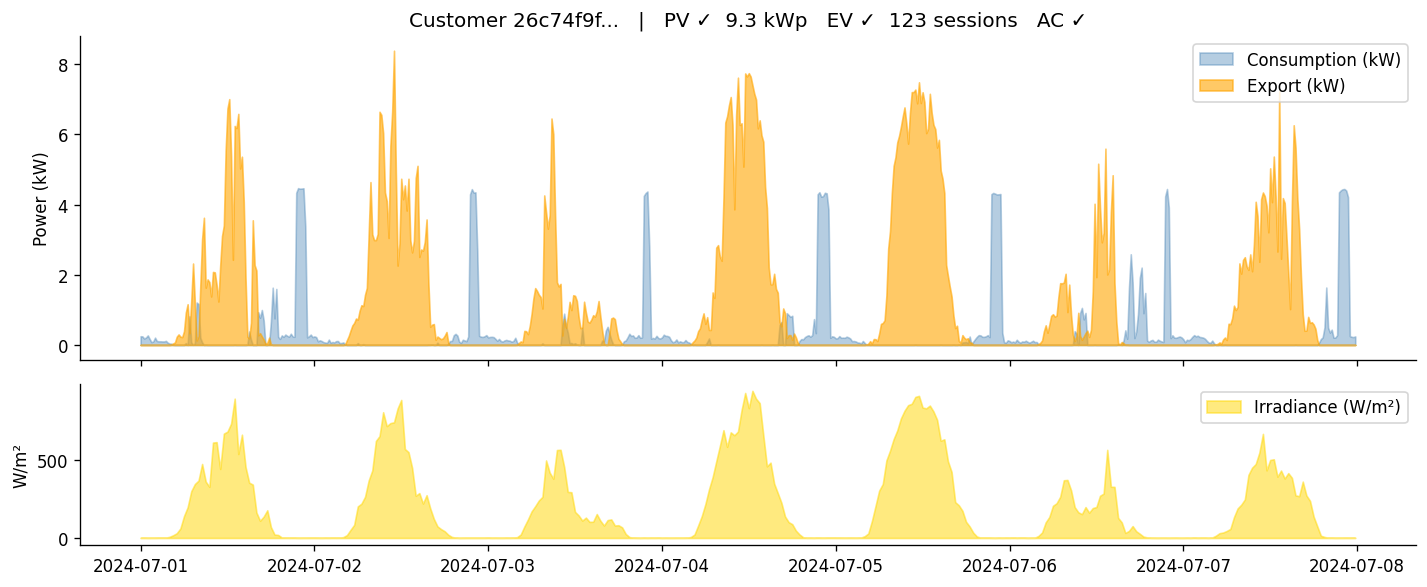

In [15]:
# ── Plot: load profile for one week in July ────────────────────────────────────
df = customer_df.copy()
df["DT_UTC"] = pd.to_datetime(df["DT_UTC"])
df = df.set_index("DT_UTC").sort_index()

week = df.loc["2024-07-01":"2024-07-07"]
w_week = weather.set_index("dt_utc").loc["2024-07-01":"2024-07-07"]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
ax.fill_between(week.index, week["CONSO_KWH"] * 4, alpha=0.4, label="Consumption (kW)", color="steelblue")
if "PROD_KWH" in week.columns:
    ax.fill_between(week.index, week["PROD_KWH"] * 4, alpha=0.6, label="Export (kW)", color="orange")
ax.set_ylabel("Power (kW)")
ax.legend(loc="upper right")

# Annotate detected appliances
labels = []
if pv_result and pv_result.get("has_pv"):
    kwp = (cap_result or {}).get("pv_capacity_kwp", 0)
    labels.append(f"PV ✓  {kwp:.1f} kWp")
if batt_result and batt_result.get("has_battery"):
    labels.append("Battery ✓")
if ev_result and ev_result.get("has_ev"):
    labels.append(f"EV ✓  {ev_result.get('ev_total_sessions', 0)} sessions")
if ac_result and ac_result.get("has_ac"):
    labels.append("AC ✓")
if hp_result and hp_result.get("has_hp"):
    labels.append(f"HP ✓  {hp_result.get('hp_type', '')}")
if labels:
    ax.set_title(f"Customer {DEMO_ID[:8]}...   |   " + "   ".join(labels))
else:
    ax.set_title(f"Customer {DEMO_ID[:8]}...   (no appliances detected)")

ax2 = axes[1]
ax2.fill_between(w_week.index, w_week["global_rad_W"], alpha=0.5, color="gold", label="Irradiance (W/m²)")
ax2.set_ylabel("W/m²")
ax2.legend(loc="upper right")

fig.tight_layout()
plt.show()

In [16]:
# ── EV charging sessions (if detected) ────────────────────────────────────────
if ev_sessions and "ev_sessions" in ev_sessions:
    sess_df = ev_sessions["ev_sessions"]
    print(f"{len(sess_df)} charging sessions detected")
    display(sess_df.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(sess_df["duration_h"].dropna(), bins=15, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Session duration (h)")
    axes[0].set_ylabel("Count")
    axes[1].hist(sess_df["energy_kWh"].dropna(), bins=15, color="orange", edgecolor="white")
    axes[1].set_xlabel("Session energy (kWh)")
    fig.suptitle("EV charging session distribution", fontsize=12)
    fig.tight_layout()
    plt.show()
elif ev_result:
    print(f"EV prob={ev_result['prob_ev']:.2f} — below threshold or no detailed sessions")

EV prob=0.85 — below threshold or no detailed sessions


---
## 2  Train Models

`scripts/train_models.py` and the trainers under `re_nilm.training.trainers` cover four independently retrainable artifacts:

| Component | Trainer class | Output |
|---|---|---|
| AC detector | `ACDetectorTrainer` | `models/ac_detector_v1.joblib` |
| HP detector | `HPDetectorTrainer` | `models/hp_detector_v1.joblib` |
| AC disaggregator | `ACDisaggregatorTrainer` | `models/ac_disaggregator_v1.pkl` (+ `_features.json` sidecar) |
| HP disaggregator | `HPDisaggregatorTrainer` | `models/hp_disaggregator_v1.joblib` (+ `_features.json` sidecar) |

All four consume the same raw `all_sources_load_with_weather.parquet` (columns: `type`, `source`, `dt_utc`, `glob_rad`, `value_kw_mean`, `id_customer`, `temp`). Detector trainers also accept a pre-computed feature table.

Skip the cells whose artifacts already exist on disk and load fine. The project pins scikit-learn to `>=1.3,<1.4`; regenerate inside this `.venv` if loading fails with pickle, `_loss`, or NumPy `BitGenerator` errors.

The equivalent CLI for any subset is `python scripts/train_models.py --models <comma-list>` (e.g. `--models ac_disaggregator` to retrain only that one).

In [1]:
TRAINING_DATA = REPO / "data" / "processed_data" / "all_sources_load_with_weather.parquet"
MODELS_DIR    = REPO / "models"
MODELS_DIR.mkdir(exist_ok=True)

if not TRAINING_DATA.exists():
    print("Training data not found at:", TRAINING_DATA)
    print("Expected: all_sources_load_with_weather.parquet — raw 15-min time series")
    print("Columns: [type, source, dt_utc, glob_rad, value_kw_mean, id_customer, temp]")
    print("Skipping training — models will be loaded from models/ if present.")
else:
    df_train = pd.read_parquet(TRAINING_DATA)
    is_raw = "type" in df_train.columns and "value_kw_mean" in df_train.columns
    print(f"Training data: {len(df_train):,} rows, {df_train['id_customer'].nunique():,} customers")
    print("Format:", "raw time series" if is_raw else "pre-computed feature table")
    print("Columns:", df_train.columns.tolist())
    if is_raw:
        print("Type breakdown:", df_train["type"].value_counts().to_dict())

NameError: name 'REPO' is not defined

In [27]:
# Train AC detector
# The trainer auto-detects raw time series and runs feature extraction internally.
if TRAINING_DATA.exists():
    from re_nilm.training.trainers.ac_detector_trainer import ACDetectorTrainer

    ac_trainer = ACDetectorTrainer(test_size=0.2)
    ac_trainer.fit(df_train)
    metrics = ac_trainer.evaluate()
    print(f"AC detector — F1: {metrics['f1']:.3f}  (test n={metrics['n_test']})")  
    print(metrics.get("report", ""))

    ac_trainer.save(MODELS_DIR / "ac_detector_v1.joblib")
    print("Saved:", MODELS_DIR / "ac_detector_v1.joblib")
else:
    print("Skipping AC training (training data not found)")

22:19:20 [ACDetectorTrainer] Raw time series detected — running feature extraction
22:19:32 [ACDetectorTrainer] Feature table: 91 customers
22:19:33 [ACDetectorTrainer] Fitted. F1=0.841 on 19 test samples
22:19:33 [ACDetectorTrainer] Model saved → /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/models/ac_detector_v1.joblib


AC detector — F1: 0.841  (test n=19)
              precision    recall  f1-score   support

       no_ac       0.88      0.78      0.82         9
      has_ac       0.82      0.90      0.86        10

    accuracy                           0.84        19
   macro avg       0.85      0.84      0.84        19
weighted avg       0.85      0.84      0.84        19

Saved: /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/models/ac_detector_v1.joblib


In [28]:
# Train HP detector
# The trainer auto-detects raw time series and runs feature extraction internally.
if TRAINING_DATA.exists():
    from re_nilm.training.trainers.hp_detector_trainer import HPDetectorTrainer

    hp_trainer = HPDetectorTrainer(test_size=0.2)
    hp_trainer.fit(df_train)
    metrics = hp_trainer.evaluate()
    print(f"HP detector — F1: {metrics['f1']:.3f}  (test n={metrics['n_test']})")  
    print(metrics.get("report", ""))

    hp_trainer.save(MODELS_DIR / "hp_detector_v1.joblib")
    print("Saved:", MODELS_DIR / "hp_detector_v1.joblib")
else:
    print("Skipping HP training (training data not found)")

22:19:33 [HPDetectorTrainer] Raw time series detected — running feature extraction
22:19:48 [HPDetectorTrainer] Feature table: 88 customers
22:19:48 [HPDetectorTrainer] Fitted. F1=0.831 on 18 test samples
22:19:48 [HPDetectorTrainer] Model saved → /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/models/hp_detector_v1.joblib


HP detector — F1: 0.831  (test n=18)
              precision    recall  f1-score   support

       no_hp       0.78      0.88      0.82         8
   winter_hp       0.80      0.67      0.73         6
   summer_hp       1.00      1.00      1.00         4

    accuracy                           0.83        18
   macro avg       0.86      0.85      0.85        18
weighted avg       0.83      0.83      0.83        18

Saved: /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/models/hp_detector_v1.joblib


In [ ]:
# Train AC disaggregator (two-stage on/off + kW regressor)
# Always expects raw time series — splits by customer and saves a JSON
# feature_cols sidecar alongside the model artifact.
if TRAINING_DATA.exists():
    from re_nilm.training.trainers.ac_disagg_trainer import ACDisaggregatorTrainer

    ac_disagg = ACDisaggregatorTrainer(test_size=0.2)
    ac_disagg.fit(df_train)
    metrics = ac_disagg.evaluate()
    print(
        f"AC disaggregator — F1(ac_on): {metrics['f1_ac_on']:.3f}  "
        f"MAE(ac_kw): {metrics['mae_ac_kw']:.3f} kW  "
        f"({metrics['n_train_users']}/{metrics['n_test_users']} train/test users)"
    )

    ac_disagg.save(MODELS_DIR / "ac_disaggregator_v1.pkl")
    print("Saved:", MODELS_DIR / "ac_disaggregator_v1.pkl")
    print("       ", MODELS_DIR / "ac_disaggregator_v1_features.json")
else:
    print("Skipping AC disaggregator training (training data not found)")


In [ ]:
# Train HP disaggregator (two-stage on/off + ratio regressor)
# Trains only on customers labelled winter_hp and drops PV-heavy customers
# (>=3% export rows), matching the legacy behaviour.
if TRAINING_DATA.exists():
    from re_nilm.training.trainers.hp_disagg_trainer import HPDisaggregatorTrainer

    hp_disagg = HPDisaggregatorTrainer(test_size=0.2)
    hp_disagg.fit(df_train)
    metrics = hp_disagg.evaluate()
    print(
        f"HP disaggregator — F1(hp_on): {metrics['f1_hp_on']:.3f}  "
        f"MAE(hp_kw): {metrics['mae_hp_kw']:.3f} kW  "
        f"({metrics['n_train_users']}/{metrics['n_test_users']} train/test users)"
    )

    hp_disagg.save(MODELS_DIR / "hp_disaggregator_v1.joblib")
    print("Saved:", MODELS_DIR / "hp_disaggregator_v1.joblib")
    print("       ", MODELS_DIR / "hp_disaggregator_v1_features.json")
else:
    print("Skipping HP disaggregator training (training data not found)")


---
## 3  Small Portfolio (N customers)

Run heuristic detectors over a bounded subset of the filtered customer index. This is useful for fast iteration before launching the full orchestrator.

This direct path does not write step checkpoints. Use it to inspect detector behavior, not to produce production outputs. For production/resumable runs, use Section 4 or `scripts/run_pipeline.py`.

In [14]:
from tqdm.auto import tqdm
from re_nilm.detectors.ac import ACDetector
from re_nilm.detectors.heat_pump import HeatPumpDetector

N_CUSTOMERS = 40  # change to taste
sample_ids = all_ids[:N_CUSTOMERS]

pv_det   = PVDetector(corr_threshold=0.3, min_yearly_prod_kwh=1.0)
pv_cap   = PVCapacityEstimator(bootstrap_n=100)   # fewer bootstraps for speed
batt_det = BatteryDetector(enforce_pv_required=True)
ev_det   = EVDetector(prob_threshold=0.3)

ac_path = REPO / "models" / "ac_detector_v1.joblib"
hp_path = REPO / "models" / "hp_detector_v1.joblib"
ac_det = ACDetector.load(ac_path) if ac_path.exists() else None
hp_det = HeatPumpDetector.load(hp_path) if hp_path.exists() else None

rows = []
for cid in tqdm(sample_ids, desc="Detecting"):
    df = load_customer_from_index(cid, index)
    if df.empty:
        continue

    pv  = pv_det.predict_customer(df, weather) or {"customer_id": cid, "has_pv": False, "prob_pv": 0.0}
    cap = pv_cap.estimate(df, pv, weather) if pv.get("has_pv") else {}
    bat = batt_det.predict_customer(df, weather, pv_result=pv) or {}
    ev  = ev_det.predict_customer(df, weather) or {}
    ac  = ac_det.predict_customer(df, weather) if ac_det else {}
    hp  = hp_det.predict_customer(df, weather) if hp_det else {}

    row = {"customer_id": cid}
    row.update({k: v for k, v in pv.items() if k != "customer_id"})
    row.update({k: v for k, v in cap.items() if k != "customer_id"})
    row.update({k: v for k, v in bat.items() if k not in row})
    row.update({k: v for k, v in ev.items() if k not in row})
    row.update({k: v for k, v in ac.items() if k not in row})
    row.update({k: v for k, v in hp.items() if k not in row})
    rows.append(row)

sample_results = pd.DataFrame(rows)
print(f"Processed {len(sample_results)} customers")
sample_results.reindex(columns=["customer_id", "has_pv", "pv_capacity_kwp", "has_battery", "has_ev", "has_ac", "has_hp", "prob_ev", "prob_ac", "prob_hp"]).head(8)

/Users/alan/Desktop/ETH/cs_re/Mest_RE_25/.venv/lib/python3.9/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.3.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/alan/Desktop/ETH/cs_re/Mest_RE_25/.venv/lib/python3.9/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.3.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/alan/Desktop/ETH/cs_re/Mest_RE_25/.venv/lib/python3.9/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unp

Processed 40 customers


,customer_id,has_pv,pv_capacity_kwp,has_battery,has_ev,has_ac,has_hp,prob_ev,prob_ac,prob_hp
0,26c3e729c270d4e4133f88d4b5b344a87ef91a3b,False,NaN,False,False,False,False,0.000,0.314307,0.086241
1,26c74f9f3492de1182f552e80900588ac2cfae87,True,9.250832,False,True,True,False,0.854,0.781827,0.009392
2,26c83264040f52f6c1fff1a42b020d15e69663df,False,NaN,False,True,False,False,0.909,0.364114,0.206368
3,26c83375ef3a6a11c779fe4d50da20bcaeb3bec2,False,NaN,False,False,False,False,0.000,0.544316,0.259092
4,26c8aa6302e1c80e253f2176555767154bef9765,True,10.895656,False,True,True,True,0.922,0.641004,0.524912
5,26c8d7905df37b01e6c2bda4ea39d8dac7c7d4d1,True,2.377274,False,False,False,False,0.000,0.311603,0.024331
6,26d008f8b40bee32e849189471c0cdee233e06b8,True,0.102074,False,False,False,False,0.000,0.455214,0.034046
7,26d2b80379cbc3c9c1eaecfd4c1e617c4f5bde75,False,NaN,False,False,False,False,0.000,0.295339,0.210063


In [8]:
# ── Detection rates ────────────────────────────────────────────────────────────
n_total = len(sample_results)
rates = {
    "PV":      sample_results["has_pv"].sum()      if "has_pv"      in sample_results.columns else 0,
    "Battery": sample_results["has_battery"].sum()  if "has_battery"  in sample_results.columns else 0,
    "EV":      sample_results["has_ev"].sum()       if "has_ev"       in sample_results.columns else 0,
    "AC":      sample_results["has_ac"].sum()       if "has_ac"       in sample_results.columns else 0,
    "HP":      sample_results["has_hp"].sum()       if "has_hp"       in sample_results.columns else 0,
}

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#f4a261", "#2a9d8f", "#264653", "#e9c46a", "#e76f51"]
bars = ax.bar(rates.keys(), [v / n_total * 100 for v in rates.values()], color=colors, width=0.55)
for bar, n in zip(bars, rates.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{n}/{n_total}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Detection rate (%)")
ax.set_title(f"Appliance detection rates — {n_total} customers")
ax.set_ylim(0, max(rates.values()) / n_total * 100 * 1.25)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.tight_layout()
plt.show()

NameError: name 'sample_results' is not defined

In [11]:
sample_results["battery_status"].value_counts(dropna=False).head(20)

battery_status
ERROR: module 'numpy' has no attribute 'trapezoid'    85
skipped_no_pv                                         12
REJECTED: No Matched Profiles                          3
Name: count, dtype: int64

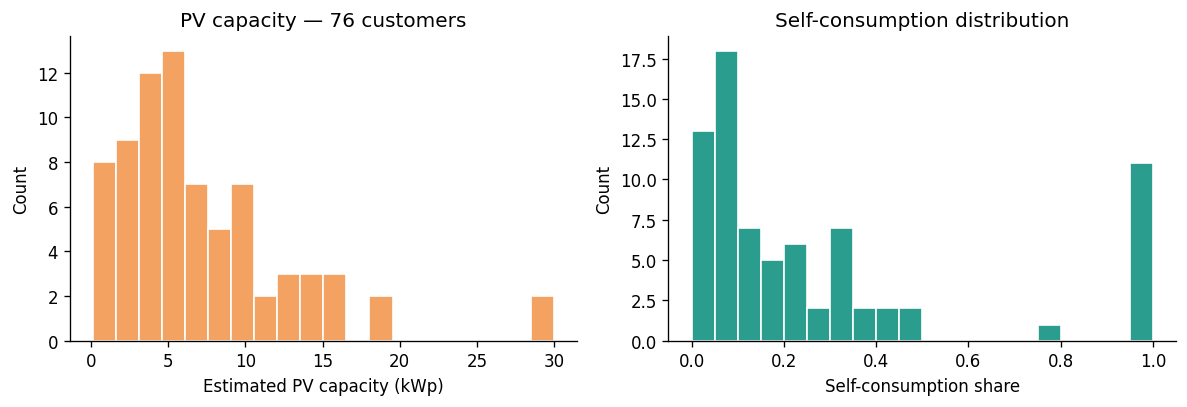

In [15]:
# ── PV capacity distribution for the sample ───────────────────────────────────
pv_only = sample_results.dropna(subset=["pv_capacity_kwp"])
pv_only = pv_only[pv_only["pv_capacity_kwp"] > 0]

if len(pv_only) > 2:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    axes[0].hist(pv_only["pv_capacity_kwp"].clip(upper=30), bins=20,
                 color="#f4a261", edgecolor="white")
    axes[0].set_xlabel("Estimated PV capacity (kWp)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"PV capacity — {len(pv_only)} customers")

    if "sc_share" in pv_only.columns:
        axes[1].hist(pv_only["sc_share"].dropna().clip(0, 1), bins=20,
                     color="#2a9d8f", edgecolor="white")
        axes[1].set_xlabel("Self-consumption share")
        axes[1].set_ylabel("Count")
        axes[1].set_title("Self-consumption distribution")

    fig.tight_layout()
    plt.show()
else:
    print("Too few PV customers in sample to plot — try increasing N_CUSTOMERS")

---
## 4  Full Portfolio

This is the production path. The orchestrator loads weather, builds the filtered customer index, runs each configured detector/estimator, writes per-step parquet outputs, and joins the scalar tables into `results_all_customers.parquet`.

Two paths are shown:

- **Path A** runs the orchestrator from the notebook. It is opt-in because a full portfolio can take a long time.
- **Path B** loads existing pipeline results and is the recommended default for analysis.

Resume behavior is step-based: if a final step output already exists and `resume=True`, that step is skipped. If a step was interrupted before its final output was compacted, the streaming checkpoint skips customers already processed in that step.

In [19]:
# ── Path A: run the full pipeline ─────────────────────────────────────────────
# Set RUN_FULL_PIPELINE = True only when you intentionally want to process the portfolio.
# For normal analysis, leave it False and load existing results in Path B.

RUN_FULL_PIPELINE = False

if RUN_FULL_PIPELINE:
    import logging
    logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%H:%M:%S")

    from re_nilm.pipeline.orchestrator import PipelineOrchestrator

    run_cfg = load_config(CONFIG_PATH)
    run_cfg["output"]["results_dir"] = str(RESULTS_DIR)
    run_cfg["output"]["figures_dir"] = str(FIGURES_DIR)

    # Laptop-friendly notebook defaults. Remove these overrides for a full production run.
    run_cfg["pipeline"]["n_workers"] = min(2, len(all_ids)) if all_ids else 1
    run_cfg["pipeline"]["batch_size"] = 200
    run_cfg["pipeline"]["skip_ac_disagg"] = True
    run_cfg["pipeline"]["skip_hp_disagg"] = True
    run_cfg["models"]["pv"]["capacity_bootstrap_n"] = 50

    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    orch = PipelineOrchestrator(run_cfg, enabled_detectors=["pv", "battery", "ac", "heat_pump", "ev"])
    orch._load_weather = lambda: weather   # reuse the weather frame loaded above
    portfolio = orch.run()
    portfolio.to_parquet(RESULTS_FILE, index=False)
    print(f"Pipeline complete: {len(portfolio):,} customers")

22:47:18 [Orchestrator] Loading weather...
22:47:18 [Orchestrator] Building customer file index...
22:47:18 [Orchestrator] 0 customers found
22:47:18 [StreamingEngine] Processing 0 customers (workers=4, batch=1000)


[CustomerIndex] Cache invalidated (empty) — rebuilding index.


Batches: 0it [00:00, ?it/s]
22:47:18 [Orchestrator] PV detection: 0 customers, 0 PV-positive
22:47:18 [StreamingEngine] Processing 0 customers (workers=4, batch=1000)
Batches: 0it [00:00, ?it/s]
22:47:18 [Orchestrator] PV capacity: 0 estimates
22:47:18 [StreamingEngine] Processing 0 customers (workers=4, batch=1000)
Batches: 0it [00:00, ?it/s]
22:47:18 [Orchestrator] Battery detection: 0 customers, 0 positive
22:47:18 [StreamingEngine] Processing 0 customers (workers=4, batch=1000)
Batches: 0it [00:00, ?it/s]
22:47:18 [Orchestrator] EV detection: 0 customers, 0 EV-positive
22:47:18 [Orchestrator] Results written → /Users/alan/Desktop/ETH/cs_re/Mest_RE_25/data/processed/out/results_all_customers.parquet (0 customers)


Pipeline complete: 0 customers


In [ ]:
# ── Path B: load existing results ─────────────────────────────────────────────
if RESULTS_FILE.exists():
    portfolio = pd.read_parquet(RESULTS_FILE)
    print(f"Loaded pipeline results: {len(portfolio):,} customers")
elif REF_CAPACITY.exists():
    # Fall back to the reference capacity output from the old pipeline
    portfolio = pd.read_parquet(REF_CAPACITY)
    # Align column names to new schema where needed
    if "has_pv_prob" in portfolio.columns and "has_pv" not in portfolio.columns:
        portfolio["has_pv"] = portfolio["has_pv_prob"] == 1.0
    if "sc_share_mean" in portfolio.columns and "sc_share" not in portfolio.columns:
        portfolio["sc_share"] = portfolio["sc_share_mean"]
    print(f"Loaded reference results: {len(portfolio):,} customers")
else:
    print("No results found — run the pipeline (RUN_FULL_PIPELINE = True) or run Section 3 first.")
    portfolio = sample_results   # use the small sample as fallback

print("Columns:", portfolio.columns.tolist())

In [3]:
# ── Portfolio summary ─────────────────────────────────────────────────────────
n = len(portfolio)
summary = {}
for col, label in [("has_pv", "PV"), ("has_battery", "Battery"), ("has_ev", "EV"),
                   ("has_ac", "AC"), ("has_hp", "HP")]:
    if col in portfolio.columns:
        k = portfolio[col].sum()
        summary[label] = {"n": int(k), "rate_%": round(k / n * 100, 1)}

print(f"Portfolio: {n:,} customers\n")
for label, s in summary.items():
    print(f"  {label:<10} {s['n']:>6,}  ({s['rate_%']}%)")

if "pv_capacity_kwp" in portfolio.columns:
    pv_valid = portfolio["pv_capacity_kwp"].dropna()
    pv_valid = pv_valid[pv_valid > 0]
    print(f"\nPV capacity (kWp): median={pv_valid.median():.1f}  "
          f"p10={pv_valid.quantile(0.1):.1f}  p90={pv_valid.quantile(0.9):.1f}")
    total_kwp = pv_valid.sum()
    print(f"Total installed PV: {total_kwp:,.0f} kWp  ({total_kwp/1000:.1f} MWp)")

NameError: name 'portfolio' is not defined

In [ ]:
# ── Plot: appliance penetration rates ─────────────────────────────────────────
if summary:
    labels_all = list(summary.keys())
    rates_all  = [summary[l]["rate_%"] for l in labels_all]
    counts_all = [summary[l]["n"] for l in labels_all]

    fig, ax = plt.subplots(figsize=(7, 3.5))
    palette = ["#f4a261", "#2a9d8f", "#264653", "#e9c46a", "#e76f51"]
    bars = ax.bar(labels_all, rates_all, color=palette[:len(labels_all)], width=0.55)
    for bar, n_pos in zip(bars, counts_all):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{n_pos:,}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Penetration (%)")
    ax.set_title(f"Portfolio appliance penetration — {n:,} customers")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    fig.tight_layout()
    plt.show()

In [ ]:
# ── Plot: PV capacity distribution ────────────────────────────────────────────
if "pv_capacity_kwp" in portfolio.columns:
    pv_df = portfolio.dropna(subset=["pv_capacity_kwp"])
    pv_df = pv_df[pv_df["pv_capacity_kwp"] > 0]

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    # Histogram
    axes[0].hist(pv_df["pv_capacity_kwp"].clip(upper=40), bins=40,
                 color="#f4a261", edgecolor="white", linewidth=0.4)
    axes[0].set_xlabel("Estimated PV capacity (kWp)")
    axes[0].set_ylabel("Number of customers")
    axes[0].set_title(f"PV capacity distribution  (n={len(pv_df):,})")
    med = pv_df["pv_capacity_kwp"].median()
    axes[0].axvline(med, color="#e63946", linestyle="--", label=f"Median {med:.1f} kWp")
    axes[0].legend()

    # Cumulative
    sorted_cap = pv_df["pv_capacity_kwp"].sort_values().values
    cumulative_mwp = sorted_cap.cumsum() / 1000
    axes[1].plot(sorted_cap, cumulative_mwp, color="#264653", linewidth=1.5)
    axes[1].set_xlabel("Individual capacity (kWp)")
    axes[1].set_ylabel("Cumulative installed (MWp)")
    axes[1].set_title("Cumulative PV capacity")

    fig.tight_layout()
    plt.show()

In [ ]:
# ── Plot: self-consumption share distribution ─────────────────────────────────
sc_col = "sc_share" if "sc_share" in portfolio.columns else "sc_share_mean"
if sc_col in portfolio.columns:
    sc = portfolio[sc_col].dropna()
    sc = sc[(sc >= 0) & (sc <= 1)]

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(sc, bins=30, color="#2a9d8f", edgecolor="white", linewidth=0.4)
    ax.set_xlabel("Self-consumption share")
    ax.set_ylabel("Count")
    ax.set_title(f"Self-consumption distribution  (n={len(sc):,})")
    ax.axvline(sc.median(), color="#e63946", linestyle="--",
               label=f"Median {sc.median():.2f}")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [ ]:
# ── Plot: appliance co-occurrence (Venn-style bar) ────────────────────────────
# Which combinations of appliances co-occur?
combos_available = [("has_pv", "has_battery"), ("has_pv", "has_ev"), ("has_ev", "has_battery")]
combo_rows = []
for c1, c2 in combos_available:
    if c1 in portfolio.columns and c2 in portfolio.columns:
        both  = (portfolio[c1] & portfolio[c2]).sum()
        only1 = (portfolio[c1] & ~portfolio[c2]).sum()
        only2 = (~portfolio[c1] & portfolio[c2]).sum()
        combo_rows.append({"combo": f"{c1[4:].upper()} only", "n": int(only1)})
        combo_rows.append({"combo": f"{c2[4:].upper()} only", "n": int(only2)})
        combo_rows.append({"combo": f"Both",               "n": int(both)})

if combo_rows:
    combo_df = pd.DataFrame(combo_rows)
    print("\nAppliance co-occurrence:")
    display(combo_df.pivot_table(index="combo", values="n", aggfunc="sum"))

In [ ]:
# ── Portfolio-level capacity scatter (capacity vs yearly production) ───────────
if REF_INDICATORS.exists() and "pv_capacity_kwp" in portfolio.columns:
    indicators = pd.read_parquet(REF_INDICATORS)
    merged = portfolio.merge(
        indicators[["customer_id", "yearly_prod", "yearly_cons"]],
        on="customer_id", how="inner"
    ).dropna(subset=["pv_capacity_kwp", "yearly_prod"])
    merged = merged[(merged.pv_capacity_kwp > 0) & (merged.yearly_prod > 0)]

    fig, ax = plt.subplots(figsize=(7, 5))
    # Expected yield line: ~1000 kWh/kWp for Switzerland
    cap_range = np.linspace(0, merged.pv_capacity_kwp.quantile(0.99), 100)
    ax.plot(cap_range, cap_range * 1000, "--", color="#e63946", linewidth=1,
            label="Reference: 1000 kWh/kWp·year")

    ax.scatter(merged.pv_capacity_kwp, merged.yearly_prod,
               alpha=0.3, s=6, color="#264653", label="Customers")
    ax.set_xlabel("Estimated PV capacity (kWp)")
    ax.set_ylabel("Measured annual PV production (kWh)")
    ax.set_title(f"Capacity vs. production validation  (n={len(merged):,})")
    ax.set_xlim(0, merged.pv_capacity_kwp.quantile(0.99) * 1.05)
    ax.set_ylim(0)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Capacity vs. production scatter: need pv_indicators_clean.parquet")

---
## CLI Reference

Everything above can also be run from the command line from the repository root.

```bash
# Install the package and notebook/PNG export dependencies
source .venv/bin/activate
pip install -e ".[dev]"

# Full configured pipeline
python scripts/run_pipeline.py --config config/re_production.yaml

# Laptop-friendly run: resume, skip heavy 15-minute disaggregation, reduce PV bootstrap work
python scripts/run_pipeline.py \
  --config config/re_production.yaml \
  --resume \
  --skip-ac-disagg \
  --skip-hp-disagg \
  --pv-bootstrap-n 50

# Run selected detectors only
python scripts/run_pipeline.py --config config/re_production.yaml --detectors pv,battery,ev

# Start fresh for all enabled steps
python scripts/run_pipeline.py --config config/re_production.yaml --no-resume

# Train AC + HP detector models when labelled training data is available
python scripts/train_models.py \
  --config config/re_production.yaml \
  --training-data data/processed/training/all_sources_load_with_weather.parquet \
  --models ac_detector,hp_detector

# Export portfolio figures as PNG files to output.figures_dir
python scripts/export_figures.py --config config/re_production.yaml

# Run tests
python -m pytest tests/unit/ -v
python -m pytest tests/integration/ -v -m integration
```

Key outputs:

- `data/processed/out/results_all_customers.parquet` is the joined scalar table.
- `data/processed/out/*_ckpt.txt` are append-only per-step checkpoint logs.
- `figures/results/*.png` contains the portfolio-level figures.
- `customer_file_index.json` records the filtered customer cohort used by the run.